# Ocular Disease

# Download & Unpack ZIP

In [1]:
from google.colab import drive, userdata
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

file_id = "andrewmvd/ocular-disease-recognition-odir5k"
download_dir = "/content/drive/MyDrive/ocular"
zip_path = os.path.join(download_dir, "ocular-disease-recognition-odir5k.zip")
extract_path = "/content/ocular"

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

# Create folder in drive if it does not exist
os.makedirs(download_dir, exist_ok=True)

# Download only if not already in drive
if not os.path.exists(zip_path):
    !kaggle datasets download -d $file_id -p $download_dir
else:
    print("Dataset already exists in Drive")

expectedFile = os.path.join(extract_path, "ODIR-5K")
# Unpack only if not already unpacked
if not os.path.exists(expectedFile):
    os.makedirs(extract_path, exist_ok=True)
    !unzip -q $zip_path -d $extract_path
else:
    print("ZIP already unpacked")

print("Download & Unpack complete")

Dataset already exists in Drive
Download & Unpack complete


# Data exploration

In [3]:
import pandas as pd

df_data = pd.read_csv('ocular/full_df.csv')
df_data.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


Displaying images and diagnoses for Patient ID: 2492


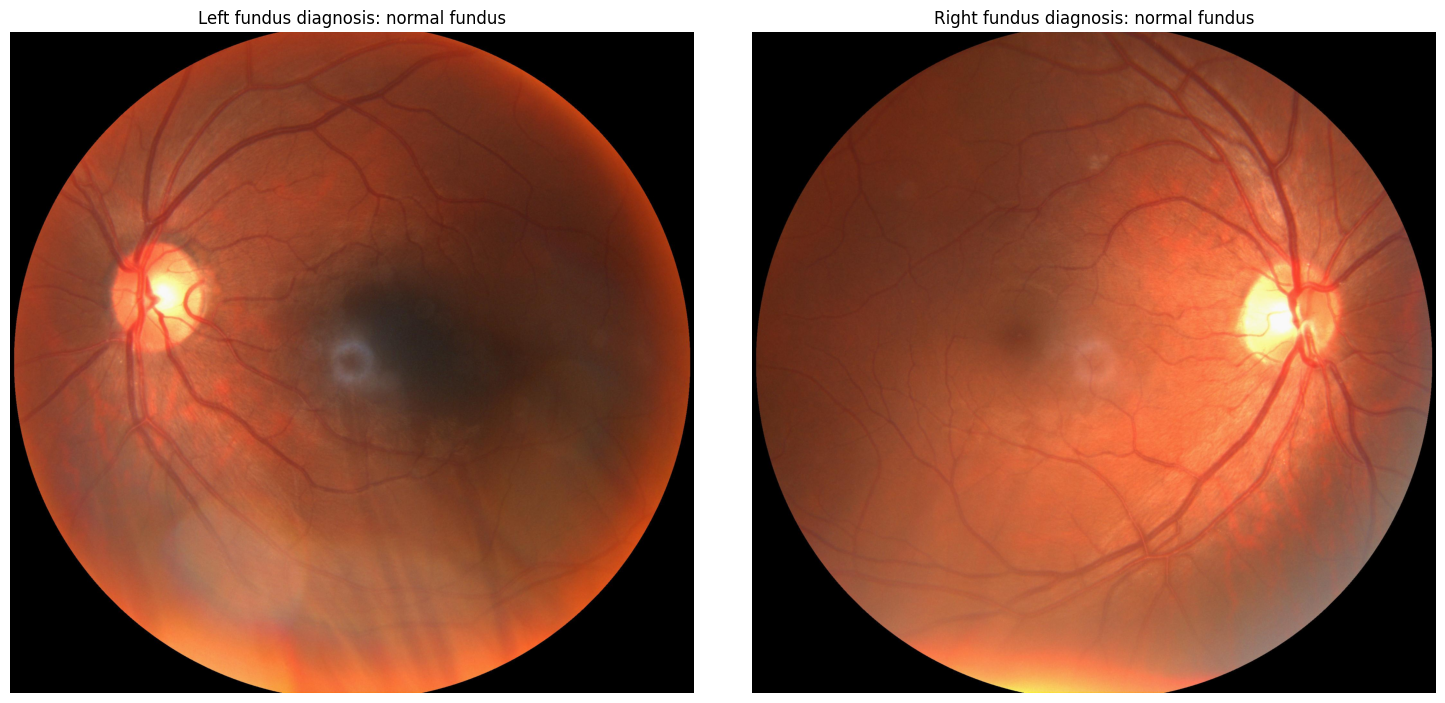

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Base path for the training images
image_base_path = '/content/ocular/ODIR-5K/ODIR-5K/Training Images/'

# Select a random patient from the dataframe
patient_row = df_data.sample(1).iloc[0]
#patient_row = df_data.iloc[0]

patient_id = patient_row['ID']
left_fundus_img_name = patient_row['Left-Fundus']
right_fundus_img_name = patient_row['Right-Fundus']
left_diagnostic = patient_row['Left-Diagnostic Keywords']
right_diagnostic = patient_row['Right-Diagnostic Keywords']

print(f"Displaying images and diagnoses for Patient ID: {patient_id}")

plt.figure(figsize=(15, 7))

# Display Left Fundus Image
plt.subplot(1, 2, 1)
if pd.notna(left_fundus_img_name) and os.path.exists(os.path.join(image_base_path, left_fundus_img_name)):
    left_img_path = os.path.join(image_base_path, left_fundus_img_name)
    img_left = Image.open(left_img_path)
    plt.imshow(img_left)
else:
    plt.text(0.5, 0.5, "Left image not available", horizontalalignment='center', verticalalignment='center', fontsize=12)
plt.title(f"Left fundus diagnosis: {left_diagnostic}")
plt.axis('off')

# Display Right Fundus Image
plt.subplot(1, 2, 2)
if pd.notna(right_fundus_img_name) and os.path.exists(os.path.join(image_base_path, right_fundus_img_name)):
    right_img_path = os.path.join(image_base_path, right_fundus_img_name)
    img_right = Image.open(right_img_path)
    plt.imshow(img_right)
else:
    plt.subplot(1, 2, 2)
    plt.text(0.5, 0.5, "Right image not available", horizontalalignment='center', verticalalignment='center', fontsize=12)
plt.title(f"Right fundus diagnosis: {right_diagnostic}")
plt.axis('off')

plt.tight_layout()
plt.show()

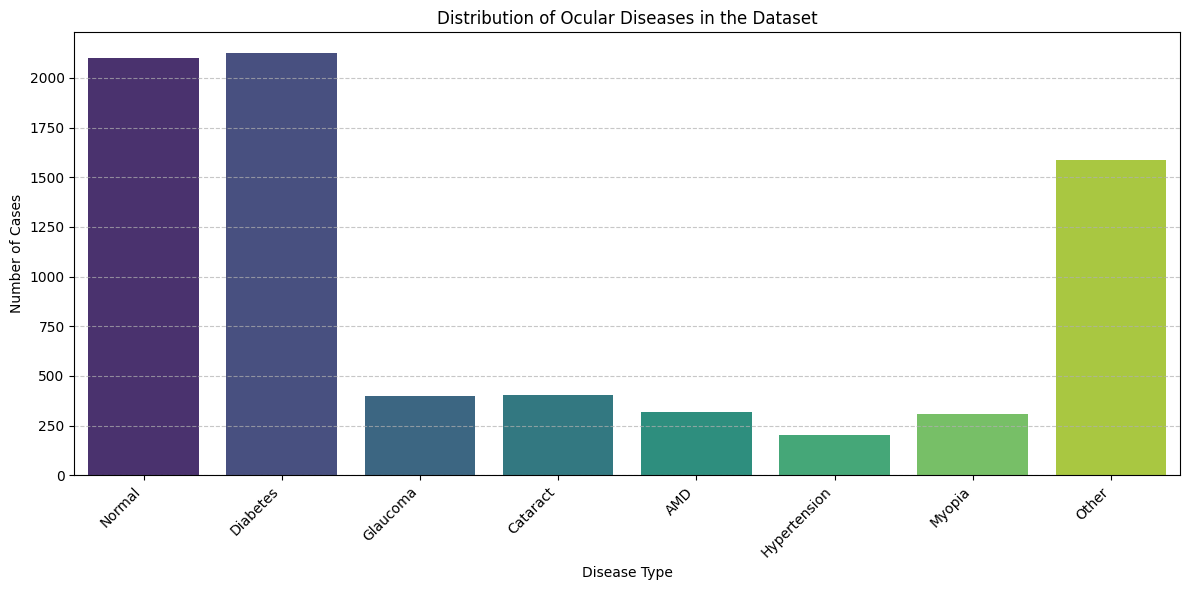

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Define the disease columns
disease_columns = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
disease_names = [
    'Normal',
    'Diabetes',
    'Glaucoma',
    'Cataract',
    'AMD',
    'Hypertension',
    'Myopia',
    'Other'
]

# Calculate the total count for each disease
disease_counts = df_data[disease_columns].sum()
disease_counts.index = disease_names

# Plotting the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=disease_counts.index, y=disease_counts.values, palette='viridis', hue=disease_counts.index, legend=False)
plt.title('Distribution of Ocular Diseases in the Dataset')
plt.xlabel('Disease Type')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Step 1 / Dataset preparation






In [6]:
training_path = "/content/ocular/ODIR-5K/ODIR-5K/Training Images/*.jpg"

import glob

tifs = glob.glob(training_path, recursive=True)

# Sanity check
print("Number of files:", len(tifs))

Number of files: 7000


In [7]:
import random
import numpy as np
import os

random.seed(42)

patient_ids = df_data['ID'].unique().tolist()
random.shuffle(patient_ids)

def createPatientFolds(patient_ids, nFolds=5):
    id_folds = np.array_split(patient_ids, nFolds)

    file_folds = []
    for id_fold in id_folds:
        id_set = set(id_fold)
        # Deduplicate — keep one row per patient
        fold_rows = df_data[df_data['ID'].isin(id_set)].drop_duplicates(subset='ID')

        fold_files = []
        for _, row in fold_rows.iterrows():
            for col in ['Left-Fundus', 'Right-Fundus']:
                fname = row[col]
                if isinstance(fname, str):
                    full_path = os.path.join(
                        'input', 'ocular-disease-recognition-odir5k',
                        'ODIR-5K', 'ODIR-5K', 'Training Images', fname
                    )
                    fold_files.append(full_path)
        file_folds.append(fold_files)

    return file_folds

folds = createPatientFolds(patient_ids, nFolds=5)

for i, fold in enumerate(folds):
    print(f"Fold {i+1}: {len(fold)} images")

Fold 1: 1344 images
Fold 2: 1344 images
Fold 3: 1344 images
Fold 4: 1342 images
Fold 5: 1342 images


In [8]:
# Assign folds
trainFiles = list(folds[0]) + list(folds[1]) + list(folds[2])
valFiles   = list(folds[3])
testFiles  = list(folds[4])

# Sanity check
print("Train:", len(trainFiles))
print("Val:", len(valFiles))
print("Test:", len(testFiles))

Train: 4032
Val: 1342
Test: 1342


In [9]:
imgSize = 224 # Standard image size for models
nBands = 3    # RGB images have 3 channels

# Define the mapping from disease labels to integer IDs
disease_to_id = {
    'N': 0, 'D': 1, 'G': 2, 'C': 3, 'A': 4, 'H': 5, 'M': 6, 'O': 7
}

# Define the number of classes for the target (8 diseases in total)
nClasses = len(disease_to_id)

print(f"Image size: {imgSize}x{imgSize}")
print(f"Number of bands (channels): {nBands}")
print(f"Number of disease classes: {nClasses}")

Image size: 224x224
Number of bands (channels): 3
Number of disease classes: 8


In [10]:
import tensorflow as tf

def serializeTFR_ocular(image_bytes, label_one_hot):
    # Ensure label is a float32 array for consistent serialization
    label_one_hot = label_one_hot.astype(np.float32)

    feature = {
        'image_raw': tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_bytes])),
        'label': tf.train.Feature(bytes_list=tf.train.BytesList(value=[label_one_hot.tobytes()]))
    }
    example = tf.train.Example(features=tf.train.Features(feature=feature))
    return example.SerializeToString()

In [11]:
import ast
from PIL import Image
import numpy as np
import os

def writeTFRecord_ocular(file_paths, df_labels, tfrecordPath):
    with tf.io.TFRecordWriter(tfrecordPath) as writer:
        for f_path in file_paths:
            try:
                filename = os.path.basename(f_path)

                label_row = df_labels[
                    (df_labels['Left-Fundus'] == filename) |
                    (df_labels['Right-Fundus'] == filename)
                ]

                if label_row.empty:
                    print(f"Warning: No label found for {filename}. Skipping.")
                    continue

                label_one_hot_list = label_row['target'].iloc[0]

                # Safely parse label — handles both str and list
                if isinstance(label_one_hot_list, str):
                    label_one_hot = np.array(ast.literal_eval(label_one_hot_list), dtype=np.float32)
                else:
                    label_one_hot = np.array(label_one_hot_list, dtype=np.float32)

                # Load and convert to RGB (handles grayscale and RGBA automatically)
                img = Image.open(f_path).convert('RGB')
                img = img.resize((imgSize, imgSize))
                img_array = np.array(img, dtype=np.uint8)

                image_bytes = tf.io.encode_jpeg(tf.convert_to_tensor(img_array)).numpy()

                example = serializeTFR_ocular(image_bytes, label_one_hot)
                writer.write(example)

            except Exception as e:
                print(f"Error processing {f_path}: {e}")

    print(f"Finished writing: {tfrecordPath}")

In [12]:
tfRecordOutputDir = "/content/drive/MyDrive/ocular/tfrecords"

os.makedirs(tfRecordOutputDir, exist_ok=True)

# Check if TFRecords already exist for all folds
all_tfrecords_exist = all(
    os.path.exists(os.path.join(tfRecordOutputDir, f"fold_{i}.tfrecord"))
    for i in range(len(folds))
)

if not all_tfrecords_exist:
    print("TFRecords not found, creating one for each fold.")
    for i, fold_files in enumerate(folds):
        tfrecordPath = os.path.join(tfRecordOutputDir, f"fold_{i}.tfrecord")
        print(f"Writing fold {i} to {tfrecordPath}")
        writeTFRecord_ocular(fold_files, df_data, tfrecordPath)
else:
    print("TFRecords already exist, skipping creation.")

TFRecords already exist, skipping creation.


# Parse the TFRecords to be usable in training


In [13]:
# File parser
def parseTFRecord(tfrecordFile):

    featureDescription = {
        "image_raw": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.string),
    }

    parsed = tf.io.parse_single_example(tfrecordFile,
                                        featureDescription)

    # Decode the raw image bytes as JPEG
    image = tf.io.decode_jpeg(parsed["image_raw"], channels=nBands)
    image = tf.cast(image, tf.float32) # Cast to float32 for model input

    # Decode the label bytes back to a float32 tensor
    label = tf.io.decode_raw(parsed["label"], tf.float32)
    label = tf.reshape(label, [nClasses]) # Reshape to the number of classes

    return image, label

In [14]:
# We do not parse here, because we need to shuffle before parsing.
def loadFold(foldId, tfRecordDir):
    path = f"{tfRecordOutputDir}/fold_{foldId}.tfrecord"
    return tf.data.TFRecordDataset(path)

### Preprocess sets

In [15]:
train_raw = (
    loadFold(0, tfRecordOutputDir)
    .concatenate(loadFold(1, tfRecordOutputDir))
    .concatenate(loadFold(2, tfRecordOutputDir))
)

val_raw = loadFold(3, tfRecordOutputDir)
test_raw = loadFold(4, tfRecordOutputDir)

In [16]:
# Improve generalization by data augmentation
def augment(image, label):
    # Apply color augmentations to the image
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)

    return image, label

In [17]:
# Shuffle considers a 1000 size window to shuffle
# Batch is for instead of updating the network in each image, it will update every 8 images
# Prefetch allows cpu preparing next batch while gpu training current
train_dataset = (
    train_raw
    .shuffle(1000)
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_raw
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_raw
    .map(parseTFRecord, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .prefetch(tf.data.AUTOTUNE)
)

In [18]:
# Checking standardization
for image, label in train_dataset.take(1):
    print(image[0])

tf.Tensor(
[[[-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  ...
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]]

 [[-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  ...
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]]

 [[-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  ...
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]]

 ...

 [[-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  ...
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -5.0551147]]

 [[-5.0551147 -5.0551147 -5.0551147]
  [-5.0551147 -5.0551147 -

# Step 2 / Training a Transfer Learning Model

We will use a pre-trained MobileNetV2 model from `tf.keras.applications` and adapt it for our ocular disease classification task. This involves loading the base model without its top classification layer, adding our custom classification layers, and then training it.

35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b2 (Functional)  │ (None, 7, 7, 1408)     │     8,769,374 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,132,134 (34.84 MB)

 Trainable params: 362,760 (1.38 MB)

 Non-trainable params: 8,769,374 (33.45 MB)

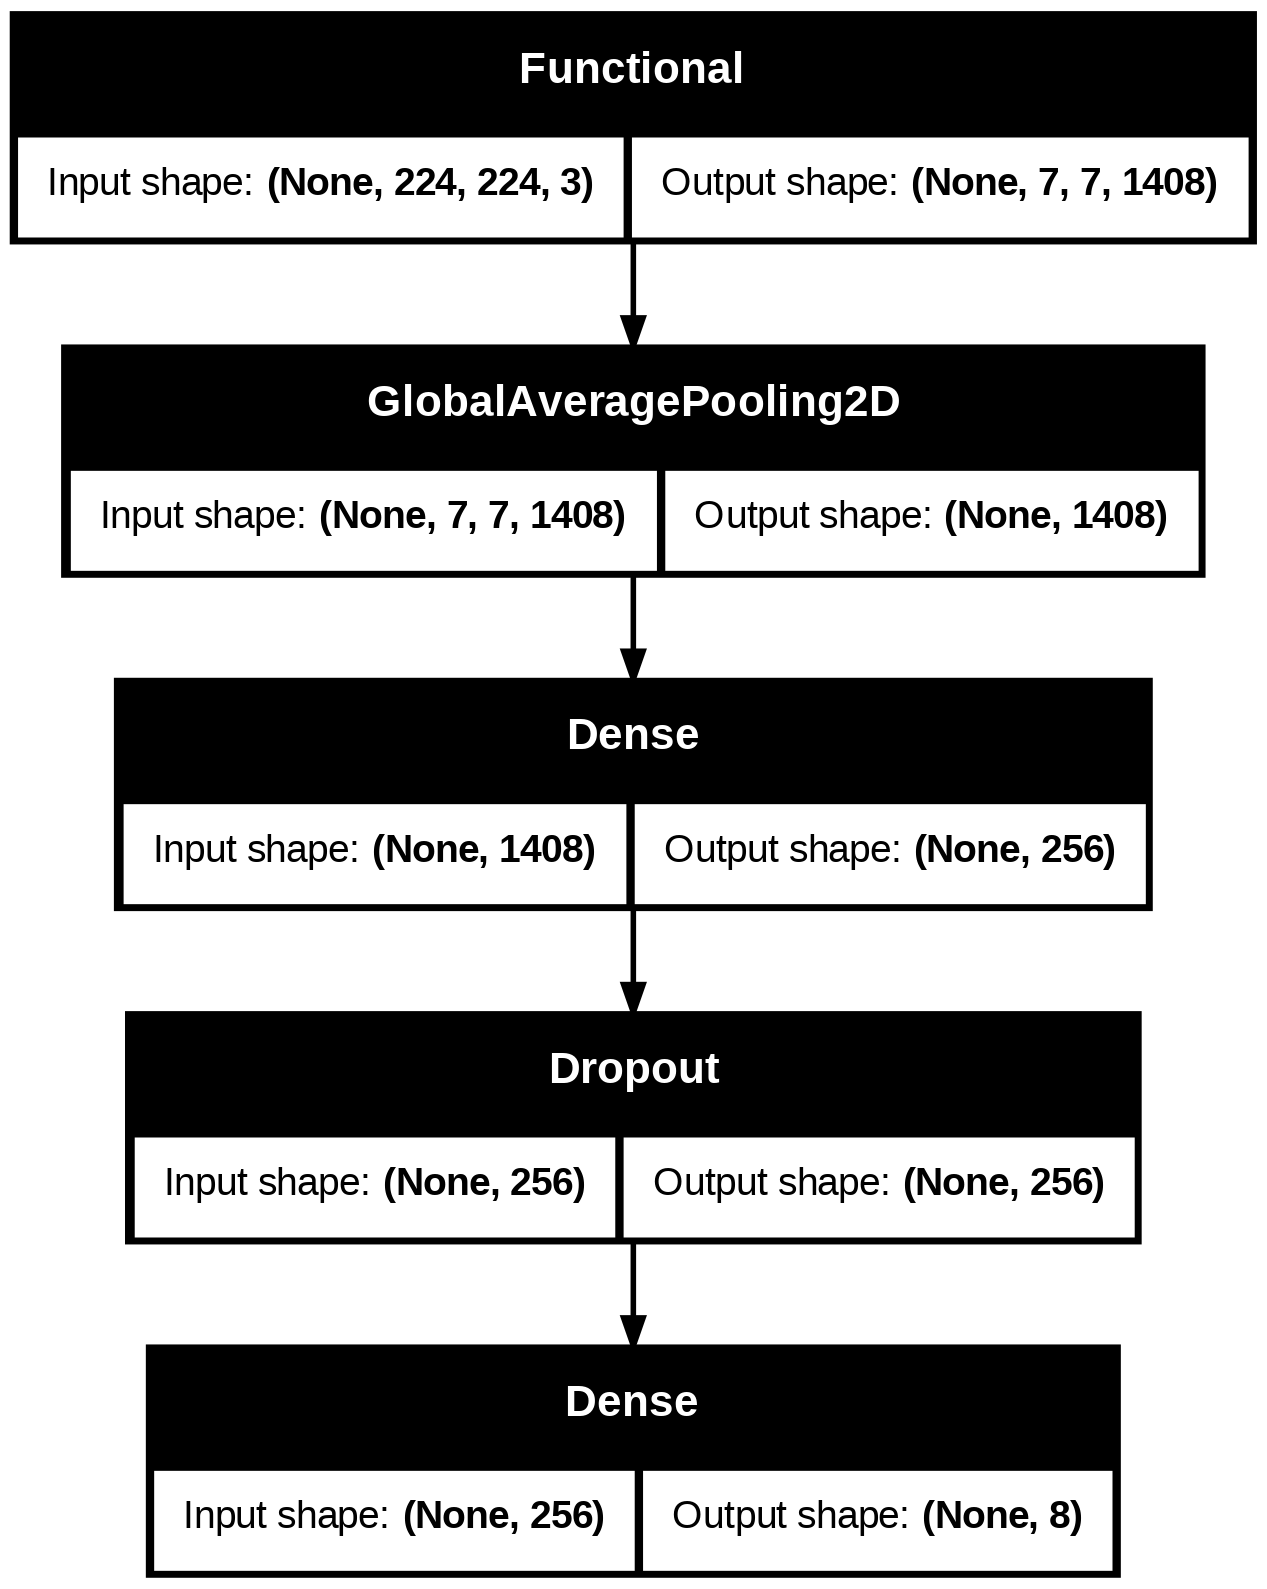

In [19]:
import tensorflow as tf

# Define model input shape (imgSize, imgSize, nBands)
IMG_SHAPE = (imgSize, imgSize, nBands)

# Load the pre-trained EfficientNetV2B2 model, excluding its top classification layer
base_model = tf.keras.applications.EfficientNetV2B2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

# Freeze the convolutional base to prevent its weights from being updated during training
base_model.trainable = False

# Add a new classification head on top of the base model
model_tl = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(nClasses, activation='sigmoid')
])

# Display the model architecture and summary
model_tl.summary()
tf.keras.utils.plot_model(model_tl, show_shapes=True)

In [20]:
# Compile the transfer learning model
model_tl.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')])

# Define a ModelCheckpoint callback to save the best model during training
checkpoint_tl = tf.keras.callbacks.ModelCheckpoint(
    "best_transfer_learning_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

# Train the transfer learning model
history_tl = model_tl.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[checkpoint_tl]
)

Epoch 1/20
    505/Unknown 51s 15ms/step - auc: 0.5689 - loss: 0.3722

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.27391, saving model to best_transfer_learning_model.keras

Epoch 1: finished saving model to best_transfer_learning_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 77s 67ms/step - auc: 0.6143 - loss: 0.3171 - val_auc: 0.6981 - val_loss: 0.2739
Epoch 2/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.6559 - loss: 0.2865
Epoch 2: val_loss improved from 0.27391 to 0.26727, saving model to best_transfer_learning_model.keras

Epoch 2: finished saving model to best_transfer_learning_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - auc: 0.6851 - loss: 0.2820 - val_auc: 0.7298 - val_loss: 0.2673
Epoch 3/20
501/505 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.6979 - loss: 0.2783
Epoch 3: val_loss improved from 0.26727 to 0.26402, saving model to best_transfer_learning_model.keras

Epoch 3: finished saving model to best_transfer_learning_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - auc: 0.7106 - loss: 0.2723 - val_auc: 0.7473 - val_loss: 0

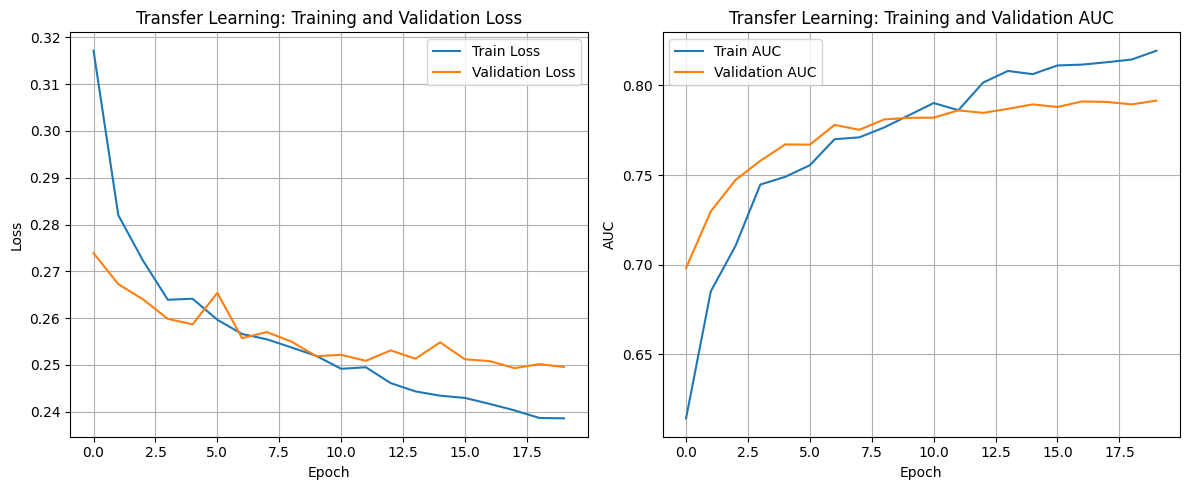

In [29]:
import matplotlib.pyplot as plt

# Plot training and validation loss for transfer learning model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transfer Learning: Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy for transfer learning model
plt.subplot(1, 2, 2)
plt.plot(history_tl.history['auc'], label='Train AUC')
plt.plot(history_tl.history['val_auc'], label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Transfer Learning: Training and Validation AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
# Load the best transfer learning model and evaluate on the test set
best_model_tl = tf.keras.models.load_model("best_transfer_learning_model.keras")

# At this stage, the model only returns [loss, auc]
evaluation_results = best_model_tl.evaluate(test_dataset)
test_loss_tl = evaluation_results[0]
test_auc_tl = evaluation_results[1]

print(f"Transfer Learning Test Loss: {test_loss_tl:.4f}")
print(f"Transfer Learning Test AUC: {test_auc_tl:.4f}")

167/167 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - auc: 0.8083 - loss: 0.2434
Transfer Learning Test Loss: 0.2434
Transfer Learning Test AUC: 0.8083


### Step 3.1 / Calculate Class Weights

Given the class imbalance observed in the dataset, we will calculate class weights to mitigate its impact during training. This makes the model pay more attention to under-represented classes.

In [23]:
disease_columns = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

# Count positives and negatives per column
pos_counts = df_data[disease_columns].sum().values
neg_counts = len(df_data) - pos_counts

# Ratio neg/pos punishes uncommon classes
pos_weight = neg_counts / np.maximum(pos_counts, 1)
pos_weight_tf = tf.constant(pos_weight, dtype=tf.float32)

print("Positives per class:", pos_counts)
print("Pos weights:", np.round(pos_weight, 2))

def recall_focused_loss(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    fn_penalty = 3.0

    bce_pos = -y_true * tf.math.log(y_pred) * pos_weight_tf * fn_penalty
    bce_neg = -(1 - y_true) * tf.math.log(1 - y_pred)

    return tf.reduce_mean(bce_pos + bce_neg)

Positives per class: [2101 2123  397  402  319  203  306 1588]
Pos weights: [ 2.04  2.01 15.1  14.9  19.04 30.49 19.89  3.03]


### Step 3.2 / Fine-Tuning the Model

We will unfreeze the last few layers of the MobileNetV2 base model and train the entire model (base + classification head) with a very low learning rate. This allows the pre-trained layers to adapt to our specific data.

In [24]:
best_model_tl = tf.keras.models.load_model("best_transfer_learning_model.keras")
base_model = best_model_tl.layers[0]
base_model.trainable = True

# Unfreeze a larger portion but with a very conservative learning rate
fine_tune_at = len(base_model.layers) - int(len(base_model.layers) * 0.5)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

best_model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=recall_focused_loss,
    metrics=[
        tf.keras.metrics.AUC(multi_label=True, name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

### Step 3.3 / Training with Learning Rate Scheduler and Class Weights

Now, we'll train the fine-tuned model for more epochs, incorporating a learning rate scheduler and the calculated class weights.

In [25]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

checkpoint_finetune = tf.keras.callbacks.ModelCheckpoint(
    "best_recall_model.keras",
    monitor="val_recall",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_recall",
    patience=8,
    mode="max",
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    mode='min',
    verbose=1
)

# batch_size has no effect on pre-batched tf.data.Dataset — removed
history_finetuned = best_model_tl.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[lr_scheduler, early_stopping, checkpoint_finetune],
)

Epoch 1/30
    502/Unknown 80s 19ms/step - auc: 0.6975 - loss: 1.9093 - precision: 0.2461 - recall: 0.4164

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_recall improved from None to 0.49703, saving model to best_recall_model.keras

Epoch 1: finished saving model to best_recall_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 96s 52ms/step - auc: 0.7165 - loss: 1.7444 - precision: 0.2505 - recall: 0.5030 - val_auc: 0.7496 - val_loss: 1.7303 - val_precision: 0.3297 - val_recall: 0.4970 - learning_rate: 1.0000e-05
Epoch 2/30
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.7532 - loss: 1.5153 - precision: 0.2444 - recall: 0.6892
Epoch 2: val_recall improved from 0.49703 to 0.64487, saving model to best_recall_model.keras

Epoch 2: finished saving model to best_recall_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - auc: 0.7567 - loss: 1.4724 - precision: 0.2413 - recall: 0.7270 - val_auc: 0.7601 - val_loss: 1.5676 - val_precision: 0.3038 - val_recall: 0.6449 - learning_rate: 1.0000e-05
Epoch 3/30
502/505 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.7687 - loss: 1.3546 - precision: 0.2355 - recall: 0.7959
Epoch 3: val_recall 

### Step 3.4 / Visualize Fine-Tuning History and Evaluate

Let's visualize the training history of the fine-tuned model and then evaluate its performance on the test set.

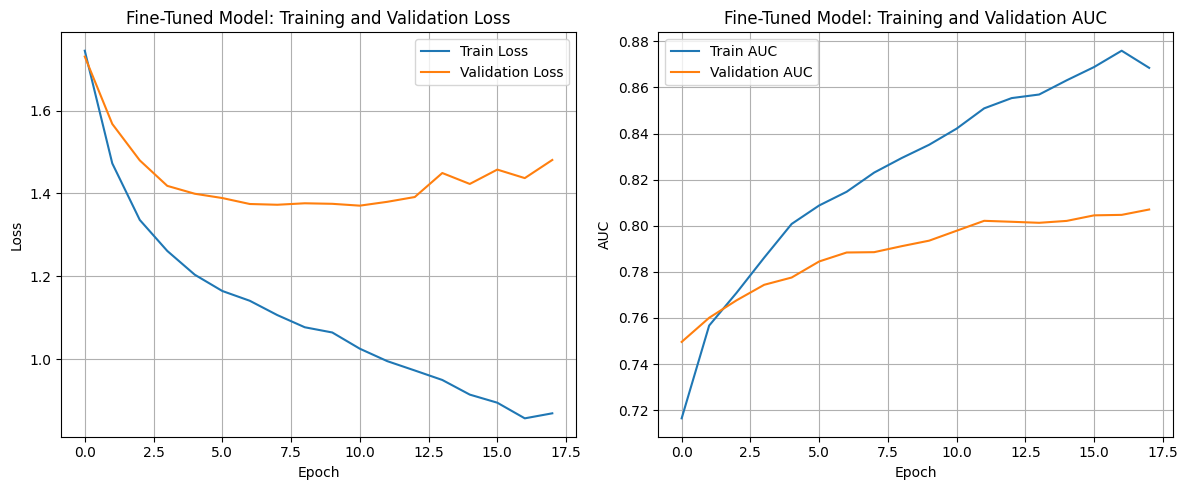

In [26]:
import matplotlib.pyplot as plt

# Plot training and validation loss for fine-tuned model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_finetuned.history['loss'], label='Train Loss')
plt.plot(history_finetuned.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-Tuned Model: Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy for fine-tuned model
plt.subplot(1, 2, 2)
plt.plot(history_finetuned.history['auc'], label='Train AUC')
plt.plot(history_finetuned.history['val_auc'], label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Fine-Tuned Model: Training and Validation AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
import tensorflow as tf

# Load the best fine-tuned model providing the custom loss function
custom_objects = {'recall_focused_loss': recall_focused_loss}

best_finetuned_model = tf.keras.models.load_model(
    "best_recall_model.keras",
    custom_objects=custom_objects
)

# Evaluate returns: [loss, auc, recall, precision] based on our compilation
evaluation_results = best_finetuned_model.evaluate(test_dataset)
test_loss_finetuned = evaluation_results[0]
test_auc_finetuned = evaluation_results[1]
test_recall_finetuned = evaluation_results[2]
test_precision_finetuned = evaluation_results[3]

print(f"Fine-Tuned Model Test Loss: {test_loss_finetuned:.4f}")
print(f"Fine-Tuned Model Test AUC: {test_auc_finetuned:.4f}")
print(f"Fine-Tuned Model Test Recall: {test_recall_finetuned:.4f}")
print(f"Fine-Tuned Model Test Precision: {test_precision_finetuned:.4f}")

167/167 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - auc: 0.8066 - loss: 1.2051 - precision: 0.3089 - recall: 0.7820
Fine-Tuned Model Test Loss: 1.2051
Fine-Tuned Model Test AUC: 0.8066
Fine-Tuned Model Test Recall: 0.7820
Fine-Tuned Model Test Precision: 0.3089


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Optimal thresholds per class (from validation set):
  Normal: threshold=0.61, val_f1=0.6467
  Diabetes: threshold=0.49, val_f1=0.5217
  Glaucoma: threshold=0.89, val_f1=0.3226
  Cataract: threshold=0.93, val_f1=0.6457
  AMD: threshold=0.87, val_f1=0.3409
  Hypertension: threshold=0.89, val_f1=0.2222
  Myopia: threshold=0.93, val_f1=0.8217
  Other: threshold=0.49, val_f1=0.2443

Classification Report:
              precision    recall  f1-score   support

      Normal       0.55      0.83      0.66       606
    Diabetes       0.32      0.76      0.45       325
    Glaucoma       0.32      0.38      0.35        47
    Cataract       0.60      0.80      0.69        46
         AMD       0.52      0.40      0.45        58
Hypertension       0.21      0.17      0.19        24
      Myopia       0.81      0.86      0.83        63
       Other       0.14      0.31      0.19       161

   micro avg       0.41      0.70      0.52      1330
   macro avg       0.43      0.56      0.48      1330


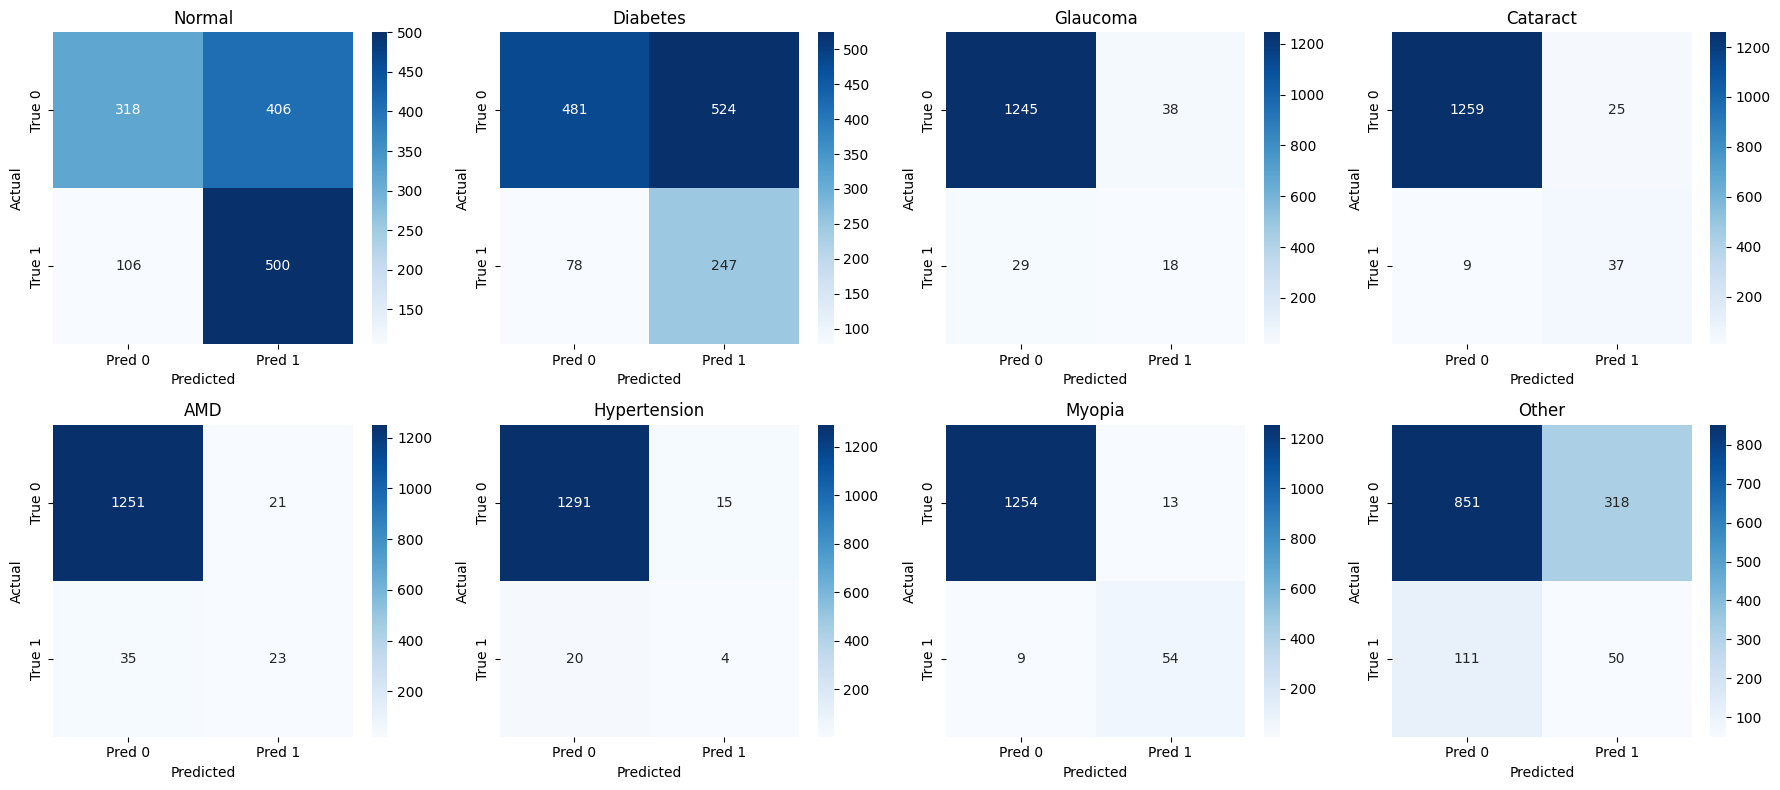

In [28]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


disease_names = ['Normal', 'Diabetes', 'Glaucoma', 'Cataract',
                 'AMD', 'Hypertension', 'Myopia', 'Other']


y_true_val, y_pred_val = [], []

for images, labels in val_dataset:
    preds = best_finetuned_model.predict(images, verbose=0)
    y_true_val.append(labels.numpy())
    y_pred_val.append(preds)

y_true_val = np.concatenate(y_true_val)
y_pred_val = np.concatenate(y_pred_val)


thresholds = np.linspace(0.01, 0.99, 50)
best_thresholds = []

print("Optimal thresholds per class (from validation set):")

for i, name in enumerate(disease_names):
    best_t, best_f1 = 0.5, 0

    for t in thresholds:
        preds_bin = (y_pred_val[:, i] >= t).astype(int)
        f1 = f1_score(y_true_val[:, i], preds_bin, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds.append(best_t)
    print(f"  {name}: threshold={best_t:.2f}, val_f1={best_f1:.4f}")


y_true, y_pred = [], []

for images, labels in test_dataset:
    preds = best_finetuned_model.predict(images, verbose=0)
    y_true.append(labels.numpy())
    y_pred.append(preds)

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)


y_pred_binary = np.zeros_like(y_pred)

for i, t in enumerate(best_thresholds):
    y_pred_binary[:, i] = (y_pred[:, i] >= t).astype(int)


print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred_binary,
    target_names=disease_names,
    zero_division=0
))


macro_f1 = f1_score(y_true, y_pred_binary, average="macro", zero_division=0)
micro_f1 = f1_score(y_true, y_pred_binary, average="micro", zero_division=0)

print("\nGlobal Metrics:")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Micro F1: {micro_f1:.4f}")


print("\nTest set positive counts per class:")
for i, name in enumerate(disease_names):
    print(f"  {name}: {int(y_true[:, i].sum())}")


print("\nPer-class AUC:")

for i, name in enumerate(disease_names):
    try:
        auc = roc_auc_score(y_true[:, i], y_pred[:, i])
        print(f"  {name}: {auc:.4f}")
    except ValueError:
        print(f"  {name}: AUC undefined (only one class present)")


fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, (name, ax) in enumerate(zip(disease_names, axes.flatten())):
    cm = confusion_matrix(y_true[:, i], y_pred_binary[:, i])

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['True 0', 'True 1']
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()